# Testing on up to 5 lines

This notebook trains a CNN to convert a 32×32 black-and-white raster image containing up to 5 lines vector coordinates.

It uses two stages:

1. **Coordinate pre-training**: the CNN first learns coordinates directly.
2. **Differentiable raster backpropagation**: the predicted vector is rasterised inside TensorFlow, then compared against the original raster image.

# Key Changes

* Image is now 32x32 to reduce size and complexit
* Lines in the synthetic data are now restricted to a set number of angles with high probability that some are certain key engineering angles.
* The model that creates the lines is now restricted to incriments of 1 degree - this may be a problem in the future
* The model learns to predict the angle of lines and not end points - could be useful for longer lines in the future

# Stopped early due to overfitting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Settings

Image size decreased so that training is faster and there are less variables.

In [2]:
IMG_SIZE = 32

N_TRAIN = 5000
N_TEST = 1000

VECTOR_EPOCHS = 150
RASTER_EPOCHS = 200

BATCH_SIZE = 32

np.random.seed(42)
tf.random.set_seed(42)

## Create synthetic training data

Each sample contains one black line on a white background.

The label is the vector form:

```text
[x1, y1, x2, y2]
```

All coordinates are normalised between 0 and 1.

This part was modified to give more probable lines, it's more likely that engineering drawings have lines on set angles. These weightings can be adjusted later.
This may also be useful if scanning images with impectly straight lines.

In [3]:
MAX_LINES = 5
MIN_LINES = 1
CONFIDENCE_THRESHOLD = 0.5

ANGLE_CLASSES = 180
VALUES_PER_LINE = 4 + ANGLE_CLASSES
# Each line = centre_x, centre_y, length, confidence, then 180 angle classes


ANGLE_WEIGHT_90 = 40
ANGLE_WEIGHT_45 = 25
ANGLE_WEIGHT_60 = 15
ANGLE_WEIGHT_30 = 10
ANGLE_WEIGHT_5 = 7
ANGLE_WEIGHT_OTHER = 3

LINE_WIDTH = 1


def build_angle_groups():
    all_angles = set(range(0, 180))

    angle_90 = {angle for angle in all_angles if angle % 90 == 0}

    angle_45 = {
        angle for angle in all_angles
        if angle % 45 == 0 and angle not in angle_90
    }

    angle_60 = {
        angle for angle in all_angles
        if angle % 60 == 0
        and angle not in angle_90
        and angle not in angle_45
    }

    angle_30 = {
        angle for angle in all_angles
        if angle % 30 == 0
        and angle not in angle_90
        and angle not in angle_45
        and angle not in angle_60
    }

    angle_5 = {
        angle for angle in all_angles
        if angle % 5 == 0
        and angle not in angle_90
        and angle not in angle_45
        and angle not in angle_60
        and angle not in angle_30
    }

    used_angles = angle_90 | angle_45 | angle_60 | angle_30 | angle_5
    angle_other = all_angles - used_angles

    return {
        "90": sorted(angle_90),
        "45": sorted(angle_45),
        "60": sorted(angle_60),
        "30": sorted(angle_30),
        "5": sorted(angle_5),
        "other": sorted(angle_other),
    }


ANGLE_GROUPS = build_angle_groups()


def choose_weighted_angle():
    """
    This controls the synthetic data distribution only.
    The model does not manually receive these weights.
    It learns the angle pattern from the examples.
    """

    group_names = ["90", "45", "60", "30", "5", "other"]

    group_weights = np.array([
        ANGLE_WEIGHT_90,
        ANGLE_WEIGHT_45,
        ANGLE_WEIGHT_60,
        ANGLE_WEIGHT_30,
        ANGLE_WEIGHT_5,
        ANGLE_WEIGHT_OTHER
    ], dtype="float32")

    group_probabilities = group_weights / np.sum(group_weights)

    selected_group = np.random.choice(group_names, p=group_probabilities)
    selected_angle = np.random.choice(ANGLE_GROUPS[selected_group])

    return selected_angle


def create_line_image(img_size=32, min_length=12, min_lines=1, max_lines=5):
    """
    Create one image containing between min_lines and max_lines random black lines.

    Label per line:
        centre_x, centre_y, length, confidence, one-hot angle

    The model will later learn to predict one of 180 angle classes.
    """

    max_pixel_length = np.sqrt(2) * (img_size - 1)

    def random_line():
        while True:
            angle_degrees = choose_weighted_angle()
            angle_radians = np.deg2rad(angle_degrees)

            cos_a = np.cos(angle_radians)
            sin_a = np.sin(angle_radians)

            max_length_x = np.inf if abs(cos_a) < 1e-8 else (img_size - 1) / abs(cos_a)
            max_length_y = np.inf if abs(sin_a) < 1e-8 else (img_size - 1) / abs(sin_a)

            max_possible_length = min(max_length_x, max_length_y)

            if max_possible_length < min_length:
                continue

            line_length = np.random.uniform(min_length, max_possible_length)

            dx = cos_a * line_length / 2
            dy = sin_a * line_length / 2

            cx_min = abs(dx)
            cx_max = (img_size - 1) - abs(dx)

            cy_min = abs(dy)
            cy_max = (img_size - 1) - abs(dy)

            if cx_min > cx_max or cy_min > cy_max:
                continue

            cx = np.random.uniform(cx_min, cx_max)
            cy = np.random.uniform(cy_min, cy_max)

            x1 = int(round(cx - dx))
            y1 = int(round(cy - dy))
            x2 = int(round(cx + dx))
            y2 = int(round(cy + dy))

            if not (0 <= x1 < img_size and 0 <= y1 < img_size):
                continue

            if not (0 <= x2 < img_size and 0 <= y2 < img_size):
                continue

            actual_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            if actual_length >= min_length:
                cx_actual = (x1 + x2) / 2
                cy_actual = (y1 + y2) / 2

                return x1, y1, x2, y2, cx_actual, cy_actual, actual_length, angle_degrees

    number_of_lines = np.random.randint(min_lines, max_lines + 1)

    lines = []

    for _ in range(number_of_lines):
        lines.append(random_line())

    lines = sorted(
        lines,
        key=lambda line: (
            line[4],
            line[5]
        )
    )

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    label_values = []

    for line in lines:
        x1, y1, x2, y2, cx, cy, length, angle_degrees = line

        draw.line((x1, y1, x2, y2), fill=0, width=LINE_WIDTH)

        angle_one_hot = np.zeros(ANGLE_CLASSES, dtype="float32")
        angle_one_hot[angle_degrees] = 1.0

        label_values.extend([
            cx / (img_size - 1),
            cy / (img_size - 1),
            length / max_pixel_length,
            1.0
        ])

        label_values.extend(angle_one_hot)

    while len(label_values) < max_lines * VALUES_PER_LINE:
        label_values.extend([0.0, 0.0, 0.0, 0.0])
        label_values.extend(np.zeros(ANGLE_CLASSES, dtype="float32"))

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array(label_values, dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=32):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(
            img_size=img_size,
            min_lines=MIN_LINES,
            max_lines=MAX_LINES
        )

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)

In [4]:
X_train, y_train = create_dataset(N_TRAIN, IMG_SIZE)
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5000, 32, 32, 1)
y_train: (5000, 920)
X_test: (1000, 32, 32, 1)
y_test: (1000, 920)


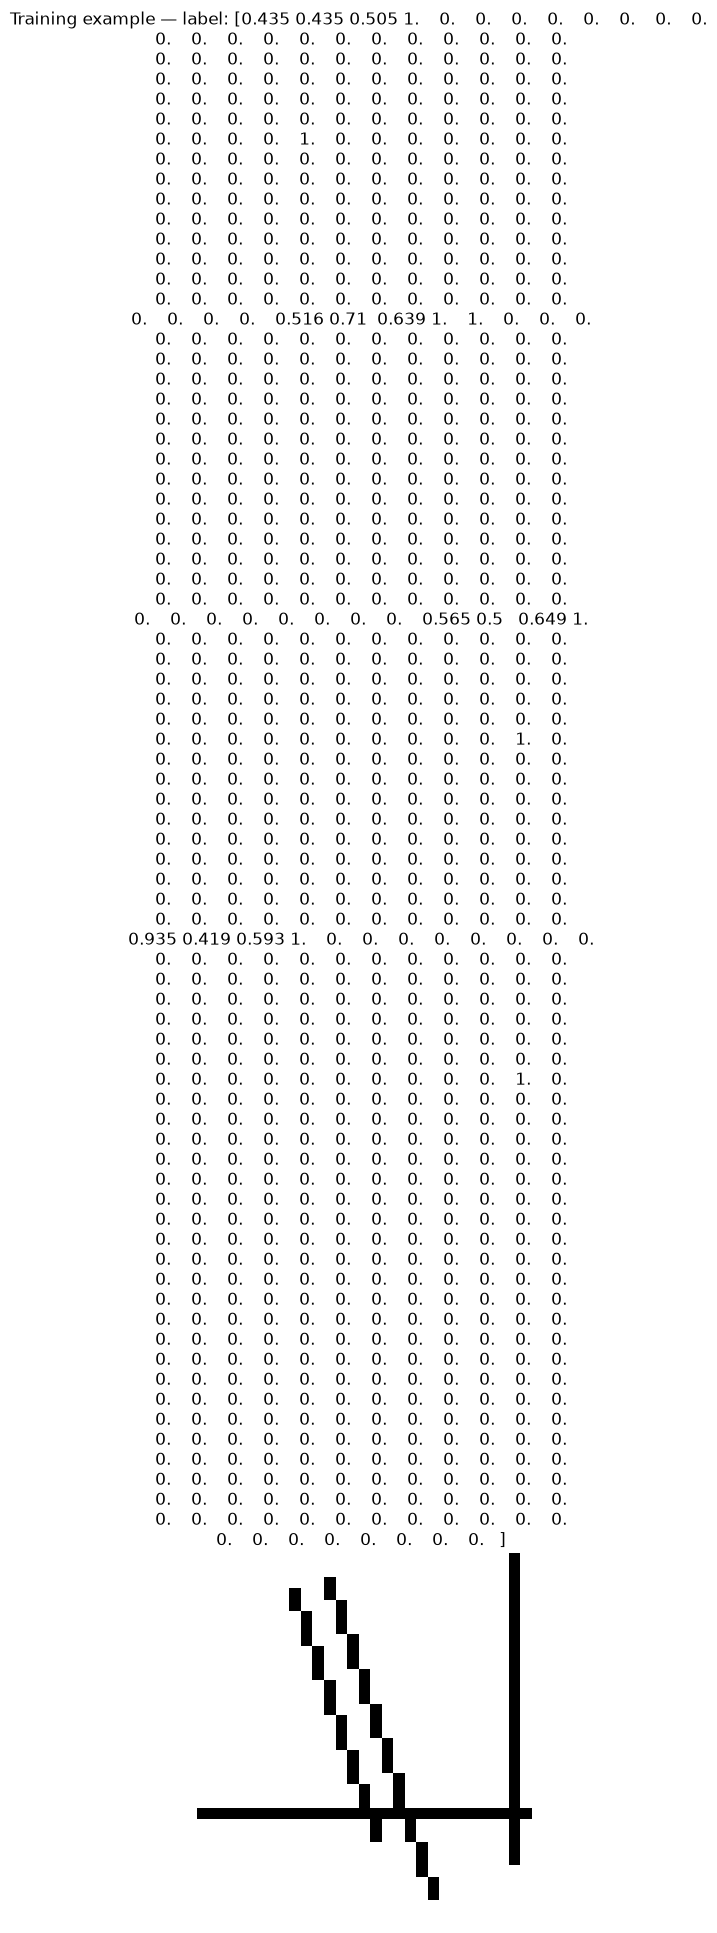

In [5]:
index = 0

plt.imshow(X_train[index].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title(f"Training example — label: {np.round(y_train[index], 3)}")
plt.axis("off")
plt.show()

## Build the CNN vector model

The CNN predicts four numbers:

```text
[x1, y1, x2, y2]
```

In [6]:
def build_vector_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="raster_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Flatten()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)

    vector_output = layers.Dense(MAX_LINES * VALUES_PER_LINE, activation=None, name="vector_output")(x)

    return models.Model(inputs=inputs, outputs=vector_output, name="vector_model")


vector_model = build_vector_model()
vector_model.summary()

Model: "vector_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ raster_input (InputLayer)            │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vector_output (Dense)                │ (None, 920)                 │         118,680 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 916,376 (3.50 MB)

 Trainable params: 916,376 (3.50 MB)

 Non-trainable params: 0 (0.00 B)

## Coordinate loss

A line is the same line if its endpoints are swapped, so this loss checks both endpoint orders and uses whichever is better.

In [7]:
def line_coordinate_loss(y_true, y_pred):
    """
    Loss for up to MAX_LINES.

    Each predicted line contains:
        centre_x, centre_y, length, confidence, angle logits

    The angle is learned as a 180-class classification problem.
    The model is not manually told which angle groups are important.
    """

    y_true = tf.reshape(y_true, (-1, MAX_LINES, VALUES_PER_LINE))
    y_pred = tf.reshape(y_pred, (-1, MAX_LINES, VALUES_PER_LINE))

    true_cxcy_length = y_true[:, :, 0:3]
    true_conf = y_true[:, :, 3]
    true_angle_one_hot = y_true[:, :, 4:]

    pred_cxcy_length = tf.sigmoid(y_pred[:, :, 0:3])
    pred_conf = tf.sigmoid(y_pred[:, :, 3])
    pred_angle_logits = y_pred[:, :, 4:]

    geometry_loss = tf.reduce_mean(
        tf.square(true_cxcy_length - pred_cxcy_length),
        axis=-1
    )

    geometry_loss = geometry_loss * true_conf

    angle_loss = tf.keras.losses.categorical_crossentropy(
        true_angle_one_hot,
        pred_angle_logits,
        from_logits=True
    )

    angle_loss = angle_loss * true_conf

    confidence_loss = tf.keras.backend.binary_crossentropy(
        true_conf,
        pred_conf
    )

    real_line_count = tf.reduce_sum(true_conf, axis=1) + 1e-8

    geometry_loss = tf.reduce_sum(geometry_loss, axis=1) / real_line_count
    angle_loss = tf.reduce_sum(angle_loss, axis=1) / real_line_count
    confidence_loss = tf.reduce_mean(confidence_loss, axis=1)

    total_loss = geometry_loss + angle_loss + confidence_loss

    return tf.reduce_mean(total_loss)

## Stage 1 — train the CNN on vector coordinates first

This prevents the raster model from collapsing into a fuzzy dot.

In [8]:
vector_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=line_coordinate_loss,
    metrics=["mae"]
)

history_vector = vector_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=VECTOR_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 3.2405 - mae: 3.2153 - val_loss: 3.0406 - val_mae: 3.4953
Epoch 2/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.9000 - mae: 4.3718 - val_loss: 2.6998 - val_mae: 4.0458
Epoch 3/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.3729 - mae: 5.6312 - val_loss: 2.1798 - val_mae: 5.2227
Epoch 4/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8682 - mae: 7.0953 - val_loss: 1.8694 - val_mae: 7.4467
Epoch 5/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5659 - mae: 8.3676 - val_loss: 1.7509 - val_mae: 8.2351
Epoch 6/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.3936 - mae: 9.6184 - val_loss: 1.6861 - val_mae: 9.4750
Epoch 7/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.2736 - mae: 10.9445 - val_loss: 1.7526 - val_mae: 10.7395
Epoch 8/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1832 - mae: 12.4195 - val_loss: 1.7694 - val_mae: 12.3362
Epoch 9/150
157/157 ━━━━━━━━━━━━━━━━

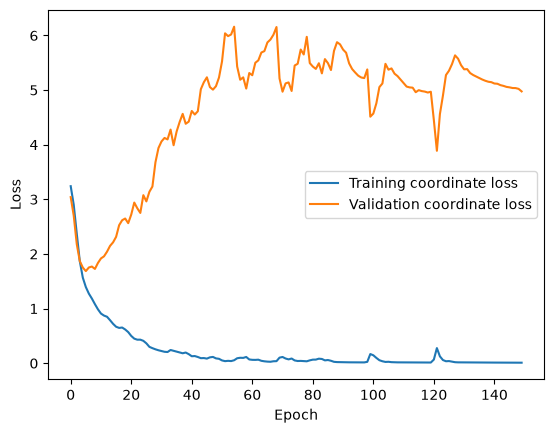

In [9]:
plt.plot(history_vector.history["loss"], label="Training coordinate loss")
plt.plot(history_vector.history["val_loss"], label="Validation coordinate loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Seems to demostrate over-fitting

## Differentiable rasteriser

This layer converts predicted vector coordinates back into a soft raster image using TensorFlow maths.

Because it is TensorFlow-based, backpropagation can pass through it.

In [10]:
class DifferentiableLineRasteriser(layers.Layer):
    def __init__(self, img_size=32, sigma=0.018, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)

        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, 1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, 1, img_size, img_size))

        angle_degrees = tf.range(0, ANGLE_CLASSES, dtype=tf.float32)
        angle_radians = angle_degrees * np.pi / 180.0

        self.angle_cos = tf.reshape(tf.cos(angle_radians), (1, 1, ANGLE_CLASSES))
        self.angle_sin = tf.reshape(tf.sin(angle_radians), (1, 1, ANGLE_CLASSES))

    def call(self, vectors):
        vectors = tf.reshape(vectors, (-1, MAX_LINES, VALUES_PER_LINE))

        pred_cx = tf.sigmoid(vectors[:, :, 0])
        pred_cy = tf.sigmoid(vectors[:, :, 1])
        pred_length = tf.sigmoid(vectors[:, :, 2])
        pred_confidence = tf.sigmoid(vectors[:, :, 3])

        pred_angle_logits = vectors[:, :, 4:]
        pred_angle_probs = tf.nn.softmax(pred_angle_logits, axis=-1)

        # During training this is soft and differentiable.
        # At final prediction we will use argmax to get an exact integer-degree angle.
        cos_a = tf.reduce_sum(pred_angle_probs * self.angle_cos, axis=-1)
        sin_a = tf.reduce_sum(pred_angle_probs * self.angle_sin, axis=-1)

        length = pred_length * np.sqrt(2.0)

        x1 = pred_cx - cos_a * length / 2.0
        y1 = pred_cy - sin_a * length / 2.0
        x2 = pred_cx + cos_a * length / 2.0
        y2 = pred_cy + sin_a * length / 2.0

        x1 = tf.reshape(x1, (-1, MAX_LINES, 1, 1))
        y1 = tf.reshape(y1, (-1, MAX_LINES, 1, 1))
        x2 = tf.reshape(x2, (-1, MAX_LINES, 1, 1))
        y2 = tf.reshape(y2, (-1, MAX_LINES, 1, 1))

        confidence = tf.reshape(pred_confidence, (-1, MAX_LINES, 1, 1))

        px = self.grid_x
        py = self.grid_y

        dx = x2 - x1
        dy = y2 - y1

        length_squared = dx * dx + dy * dy + 1e-8

        t = ((px - x1) * dx + (py - y1) * dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)

        line_darkness = tf.exp(
            -distance_squared / (2.0 * self.sigma * self.sigma)
        )

        line_darkness = line_darkness * confidence

        combined_darkness = 1.0 - tf.reduce_prod(
            1.0 - line_darkness,
            axis=1
        )

        raster = 1.0 - combined_darkness
        raster = tf.expand_dims(raster, axis=-1)

        return raster

## Weighted raster loss

Normal MSE performs badly because most pixels are white. This weighted loss gives black line pixels much more importance.

In [11]:
def weighted_raster_loss(y_true, y_pred):
    black_pixel_weight = 40.0
    weights = 1.0 + black_pixel_weight * (1.0 - y_true)
    loss = weights * tf.square(y_true - y_pred)
    return tf.reduce_mean(loss)

## Stage 2 — train through the differentiable rasteriser

This model has two losses:

1. Raster loss: predicted raster should match the input raster.
2. Coordinate loss: predicted vector should not drift away from the true vector.

The raster loss is the important Option B part.

In [12]:
raster_output = DifferentiableLineRasteriser(
    img_size=IMG_SIZE,
    sigma=0.010,
    name="raster_output"
)(vector_model.output)

training_model = models.Model(
    inputs=vector_model.input,
    outputs=[raster_output, vector_model.output],
    name="option_b_training_model"
)

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=[weighted_raster_loss, line_coordinate_loss],
    loss_weights=[1.0, 0.2],
    metrics=[["mae"], ["mae"]]
)

history_raster = training_model.fit(
    X_train,
    [X_train, y_train],
    validation_data=(X_test, [X_test, y_test]),
    epochs=RASTER_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 1.9443 - raster_output_loss: 1.9417 - raster_output_mae: 0.1032 - vector_output_loss: 0.0196 - vector_output_mae: 48.2553 - val_loss: 2.9629 - val_raster_output_loss: 1.9900 - val_raster_output_mae: 0.1067 - val_vector_output_loss: 4.8520 - val_vector_output_mae: 45.4488
Epoch 2/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.9019 - raster_output_loss: 1.8971 - raster_output_mae: 0.1061 - vector_output_loss: 0.0298 - vector_output_mae: 46.8957 - val_loss: 2.9517 - val_raster_output_loss: 1.9868 - val_raster_output_mae: 0.1091 - val_vector_output_loss: 4.8196 - val_vector_output_mae: 44.8033
Epoch 3/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.8713 - raster_output_loss: 1.8641 - raster_output_mae: 0.1061 - vector_output_loss: 0.0417 - vector_output_mae: 45.9717 - val_loss: 2.8998 - val_raster_output_loss: 1.9515 - val_raster_output_mae: 0.1088 - val_vector_output_loss: 4.7252 - val_vector_output_mae: 43.08

KeyboardInterrupt: 

In [ ]:
plt.plot(history_raster.history["loss"], label="Training total loss")
plt.plot(history_raster.history["val_loss"], label="Validation total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Test the trained model

In [ ]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def decode_prediction(prediction, img_size=32, confidence_threshold=0.5):
    prediction = prediction.reshape(MAX_LINES, VALUES_PER_LINE)

    decoded_lines = []

    for line in prediction:
        cx = sigmoid_np(line[0])
        cy = sigmoid_np(line[1])
        length_norm = sigmoid_np(line[2])
        confidence = sigmoid_np(line[3])

        angle_logits = line[4:]
        angle_degrees = int(np.argmax(angle_logits))

        if confidence >= confidence_threshold:
            length = length_norm * np.sqrt(2.0) * (img_size - 1)

            angle_radians = np.deg2rad(angle_degrees)

            dx = np.cos(angle_radians) * length / 2
            dy = np.sin(angle_radians) * length / 2

            cx_pixels = cx * (img_size - 1)
            cy_pixels = cy * (img_size - 1)

            x1 = int(round(cx_pixels - dx))
            y1 = int(round(cy_pixels - dy))
            x2 = int(round(cx_pixels + dx))
            y2 = int(round(cy_pixels + dy))

            x1 = np.clip(x1, 0, img_size - 1)
            y1 = np.clip(y1, 0, img_size - 1)
            x2 = np.clip(x2, 0, img_size - 1)
            y2 = np.clip(y2, 0, img_size - 1)

            decoded_lines.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "angle": angle_degrees,
                "confidence": confidence
            })

    return decoded_lines


sample = X_test[0:1]

predicted_vector = vector_model.predict(sample)[0]
predicted_raster = training_model.predict(sample)[0]

decoded_lines = decode_prediction(
    predicted_vector,
    img_size=IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD
)

print("Predicted lines:")

for i, line in enumerate(decoded_lines):
    print(
        f"Line {i + 1}: "
        f"({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
        f"angle={line['angle']}°, "
        f"confidence={line['confidence']:.2f}"
    )

plt.imshow(sample.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Original raster")
plt.axis("off")
plt.show()

plt.imshow(predicted_raster.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Predicted raster")
plt.axis("off")
plt.show()

## Compare several predictions

In [ ]:
for sample_index in range(5):
    sample = X_test[sample_index:sample_index + 1]
    true_vector = y_test[sample_index]
    predicted_vector = vector_model.predict(sample, verbose=0)[0]
    predicted_raster = raster_model.predict(sample, verbose=0)[0]

    print("Example", sample_index)
    print("True pixels:     ", np.round(true_vector * (IMG_SIZE - 1)).astype(int))
    print("Predicted pixels:", np.round(predicted_vector * (IMG_SIZE - 1)).astype(int))

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_raster.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Predicted raster")
    plt.axis("off")

    plt.show()

In [ ]:
This is disapointing... It predicts a single line well, but struggles with multiple lines.

(≧﹏ ≦)

## Export the predicted line as SVG

In [ ]:
def vector_to_svg(vector, img_size=32, confidence_threshold=0.5):
    """
    Converts model output into SVG.

    Expected vector shape:
        MAX_LINES * 5

    Each line:
        x1, y1, x2, y2, confidence
    """

    lines = vector.reshape(MAX_LINES, 5)

    svg_lines = []

    for line in lines:
        x1, y1, x2, y2, confidence = line

        if confidence >= confidence_threshold:
            x1 = int(round(x1 * (img_size - 1)))
            y1 = int(round(y1 * (img_size - 1)))
            x2 = int(round(x2 * (img_size - 1)))
            y2 = int(round(y2 * (img_size - 1)))

            svg_lines.append(
                f'  <line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
                f'stroke="black" stroke-width="1"/>'
            )

    svg = (
        f'<svg width="{img_size}" height="{img_size}" xmlns="http://www.w3.org/2000/svg">\n'
        f'  <rect width="100%" height="100%" fill="white"/>\n'
        + "\n".join(svg_lines) +
        f'\n</svg>'
    )

    return svg


svg_text = vector_to_svg(
    predicted_vector,
    IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD
)

print(svg_text)

with open("predicted_lines.svg", "w") as f:
    f.write(svg_text)

print("Saved predicted_lines.svg")

## What to change next

To train for longer, edit these values near the top of the notebook:

```python
VECTOR_EPOCHS = 150
RASTER_EPOCHS = 200
```

If the line is still too blurry, try reducing:

```python
sigma=0.010
```

to:

```python
sigma=0.007
```

inside the `DifferentiableLineRasteriser(...)` call.